In [3]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd


In [4]:
cation = []
anion = []
solvent = []
temperature = []
concentration = []
cation_diffusivity_simulated = []
anion_diffusivity_simulated = []
solvent_diffusivity_simulated = []
cation_diffusivity_experimental = []
anion_diffusivity_experimental = []
solvent_diffusivity_experimental = []


In [5]:
df = pd.read_csv("/global/homes/y/yuejian/project/MLFF-distill/yuejian/electrolyte_application/ablate_distillation/observables/data_for_plotting/merged_diffusivity_all_fixed.csv")
print(df.columns)


Index(['cation', 'anion', 'solvent', 'temperature', 'concentration',
       'cation_diffusivity_simulated', 'anion_diffusivity_simulated',
       'solvent_diffusivity_simulated', 'cation_diffusivity_experimental',
       'anion_diffusivity_experimental', 'solvent_diffusivity_experimental'],
      dtype='object')


In [6]:
df

,cation,anion,solvent,temperature,concentration,cation_diffusivity_simulated,anion_diffusivity_simulated,solvent_diffusivity_simulated,cation_diffusivity_experimental,anion_diffusivity_experimental,solvent_diffusivity_experimental
0,Na,OTf,TGDME,298K,0.1M,1.18,2.84,1.92,NaN,1.770,3.05
1,Na,OTf,DME,298K,0.1M,101.00,137.00,192.00,12.30,11.400,30.10
2,Na,OTf,PC,298K,0.1M,1.18,0.70,2.65,7.83,3.700,4.92
3,Na,PF6,PC,298K,0.1M,0.85,2.28,3.10,2.11,4.290,4.97
4,Na,OTf,DEGDME,298K,0.1M,7.24,8.70,11.01,7.25,5.440,11.60
5,Na,PF6,DEGDME,298K,0.1M,5.47,3.01,12.45,6.67,5.550,11.80
6,Na,PF6,DME,298K,0.1M,36.36,22.95,100.61,13.10,17.600,29.50
7,Na,OTf,DEGDME,298K,1M,0.95,0.86,2.04,1.79,2.870,5.94
8,Na,TFSI,DME,298K,1M,NaN,NaN,NaN,NaN,NaN,NaN
9,Na,PF6,DEGDME,298K,1M,1.02,1.11,2.07,NaN,2.960,4.89


/tmp/ipykernel_1066491/1710434633.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap_name, num_points)


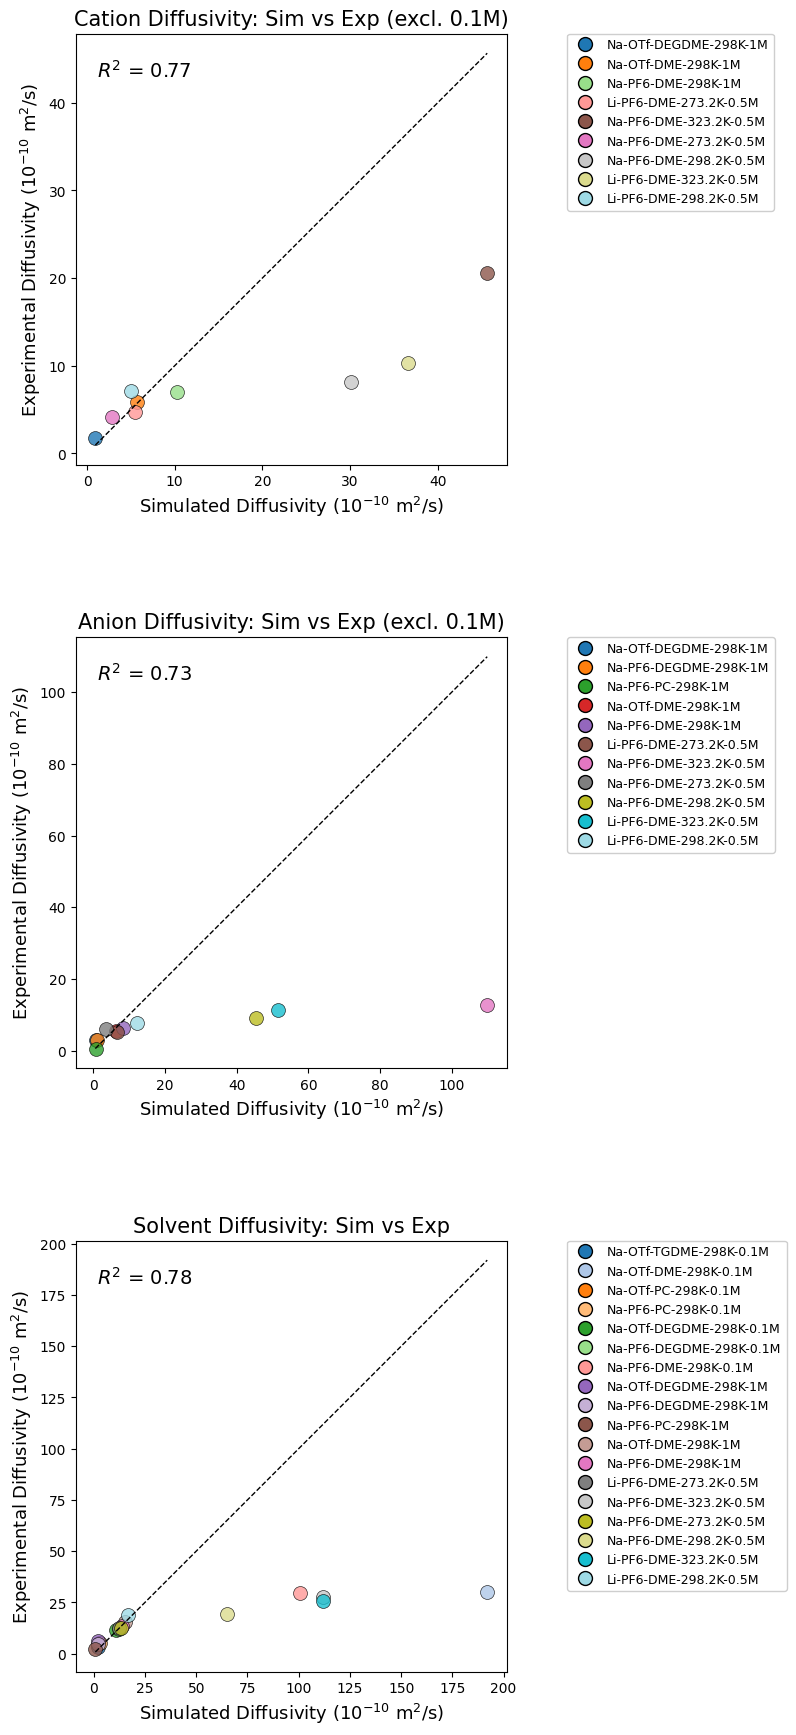

In [7]:
# Filter out rows where concentration is 0.1M for cation and anion R2
df_filtered = df.copy()
exclude_cation_anion = (df_filtered['concentration'] == '0.1M')

# Prepare cation R2 (exclude 0.1M)
mask_cation = (
    (~exclude_cation_anion) &
    (df_filtered['cation_diffusivity_simulated'].notnull()) &
    (df_filtered['cation_diffusivity_experimental'].notnull())
)
x_cation = df_filtered.loc[mask_cation, 'cation_diffusivity_simulated'].astype(float).values
y_cation = df_filtered.loc[mask_cation, 'cation_diffusivity_experimental'].astype(float).values
labels_cation = df_filtered.loc[mask_cation, ['cation', 'anion', 'solvent', 'temperature', 'concentration']].astype(str).agg('-'.join, axis=1).values

# Prepare anion R2 (exclude 0.1M)
mask_anion = (
    (~exclude_cation_anion) &
    (df_filtered['anion_diffusivity_simulated'].notnull()) &
    (df_filtered['anion_diffusivity_experimental'].notnull())
)
x_anion = df_filtered.loc[mask_anion, 'anion_diffusivity_simulated'].astype(float).values
y_anion = df_filtered.loc[mask_anion, 'anion_diffusivity_experimental'].astype(float).values
labels_anion = df_filtered.loc[mask_anion, ['cation', 'anion', 'solvent', 'temperature', 'concentration']].astype(str).agg('-'.join, axis=1).values

# Prepare solvent R2 (no exclusion)
mask_solvent = (
    (df_filtered['solvent_diffusivity_simulated'].notnull()) &
    (df_filtered['solvent_diffusivity_experimental'].notnull())
)
x_solvent = df_filtered.loc[mask_solvent, 'solvent_diffusivity_simulated'].astype(float).values
y_solvent = df_filtered.loc[mask_solvent, 'solvent_diffusivity_experimental'].astype(float).values
labels_solvent = df_filtered.loc[mask_solvent, ['cation', 'anion', 'solvent', 'temperature', 'concentration']].astype(str).agg('-'.join, axis=1).values

def plot_r2_unique_colors(ax, x, y, labels, title, colormap_name='tab20'):
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    num_points = len(x)
    cmap = cm.get_cmap(colormap_name, num_points)
    colors = [cmap(i) for i in range(num_points)]

    # Plot scatter points with unique colors
    handles = []
    for i, (xi, yi, label) in enumerate(zip(x, y, labels)):
        handle = ax.scatter([xi], [yi], alpha=0.8, color=[colors[i]], label=label, s=100, edgecolor='k', linewidth=0.5)
        handles.append(handle)

    # Plot y=x reference
    min_val = min(min(x), min(y))
    max_val = max(max(x), max(y))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
    ax.set_xlabel('Simulated Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_ylabel('Experimental Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_title(title, fontsize=15)

    # Calculate R^2
    if len(x) > 1:
        correlation_matrix = np.corrcoef(x, y)
        r2 = correlation_matrix[0, 1] ** 2
        ax.text(0.05, 0.9, f"$R^2$ = {r2:.2f}", transform=ax.transAxes, fontsize=14,
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
    ax.set_aspect('equal', adjustable='box')

    # Create legend: Show all labels
    from matplotlib.lines import Line2D
    legend_handles = []
    for lab, col in zip(labels, colors):
        legend_handles.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=col,
                   markeredgecolor='k', markersize=10, label=lab)
        )
    ax.legend(handles=legend_handles, bbox_to_anchor=(1.14, 1), loc='upper left', fontsize=9, borderaxespad=0, framealpha=0.95)

# Create 3 rows (stacked vertically), 1 column, make plots tall and wide for space and clear separation
fig, axes = plt.subplots(3, 1, figsize=(14, 18), gridspec_kw={'hspace': 0.4})  # much bigger height, enough horizontal for legend

plot_r2_unique_colors(axes[0], x_cation, y_cation, labels_cation, "Cation Diffusivity: Sim vs Exp (excl. 0.1M)", colormap_name='tab20')
plot_r2_unique_colors(axes[1], x_anion, y_anion, labels_anion, "Anion Diffusivity: Sim vs Exp (excl. 0.1M)", colormap_name='tab20')
plot_r2_unique_colors(axes[2], x_solvent, y_solvent, labels_solvent, "Solvent Diffusivity: Sim vs Exp", colormap_name='tab20')

# Adjust to give LOTS of space to legends and prevent overlap, bigger left/right margins, increase top/bottom, more vertical space
plt.subplots_adjust(left=0.10, right=0.78, bottom=0.06, top=0.97, hspace=0.36)
plt.show()


/tmp/ipykernel_1066491/354106306.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap_name, num_points)


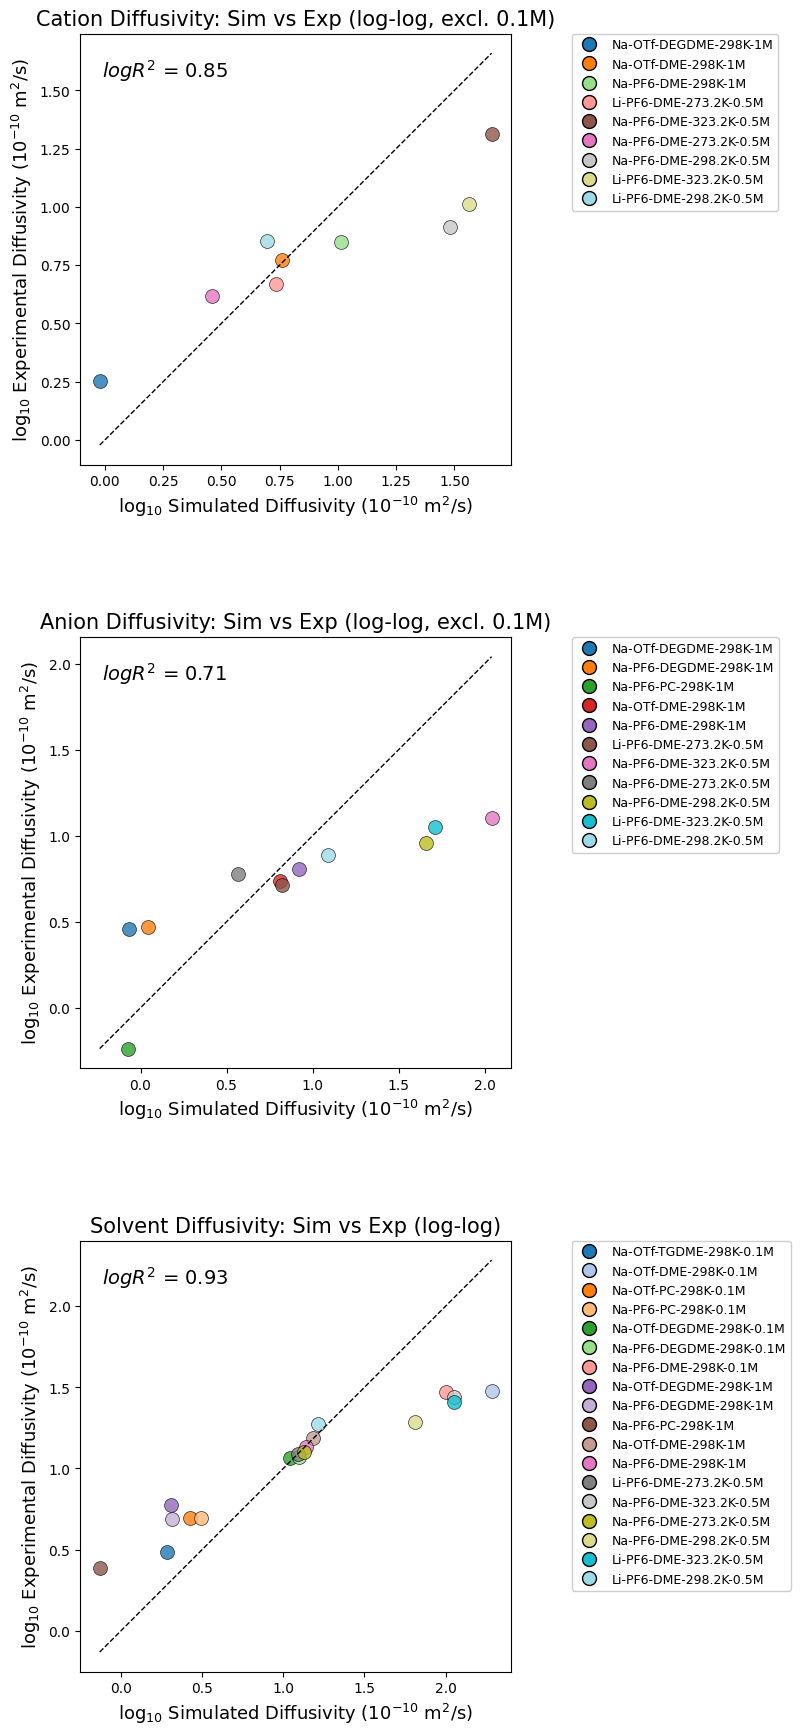

In [8]:
# Filter out rows where concentration is 0.1M for cation and anion R2
df_filtered = df.copy()
exclude_cation_anion = (df_filtered['concentration'] == '0.1M')

# Prepare cation R2 (exclude 0.1M)
mask_cation = (
    (~exclude_cation_anion) &
    (df_filtered['cation_diffusivity_simulated'].notnull()) &
    (df_filtered['cation_diffusivity_experimental'].notnull()) &
    (df_filtered['cation_diffusivity_simulated'].astype(float) > 0) &
    (df_filtered['cation_diffusivity_experimental'].astype(float) > 0)
)
x_cation = np.log10(df_filtered.loc[mask_cation, 'cation_diffusivity_simulated'].astype(float).values)
y_cation = np.log10(df_filtered.loc[mask_cation, 'cation_diffusivity_experimental'].astype(float).values)
labels_cation = df_filtered.loc[mask_cation, ['cation', 'anion', 'solvent', 'temperature', 'concentration']].astype(str).agg('-'.join, axis=1).values

# Prepare anion R2 (exclude 0.1M)
mask_anion = (
    (~exclude_cation_anion) &
    (df_filtered['anion_diffusivity_simulated'].notnull()) &
    (df_filtered['anion_diffusivity_experimental'].notnull()) &
    (df_filtered['anion_diffusivity_simulated'].astype(float) > 0) &
    (df_filtered['anion_diffusivity_experimental'].astype(float) > 0)
)
x_anion = np.log10(df_filtered.loc[mask_anion, 'anion_diffusivity_simulated'].astype(float).values)
y_anion = np.log10(df_filtered.loc[mask_anion, 'anion_diffusivity_experimental'].astype(float).values)
labels_anion = df_filtered.loc[mask_anion, ['cation', 'anion', 'solvent', 'temperature', 'concentration']].astype(str).agg('-'.join, axis=1).values

# Prepare solvent R2 (no exclusion)
mask_solvent = (
    (df_filtered['solvent_diffusivity_simulated'].notnull()) &
    (df_filtered['solvent_diffusivity_experimental'].notnull()) &
    (df_filtered['solvent_diffusivity_simulated'].astype(float) > 0) &
    (df_filtered['solvent_diffusivity_experimental'].astype(float) > 0)
)
x_solvent = np.log10(df_filtered.loc[mask_solvent, 'solvent_diffusivity_simulated'].astype(float).values)
y_solvent = np.log10(df_filtered.loc[mask_solvent, 'solvent_diffusivity_experimental'].astype(float).values)
labels_solvent = df_filtered.loc[mask_solvent, ['cation', 'anion', 'solvent', 'temperature', 'concentration']].astype(str).agg('-'.join, axis=1).values

def plot_r2_unique_colors(ax, x, y, labels, title, colormap_name='tab20'):
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    num_points = len(x)
    cmap = cm.get_cmap(colormap_name, num_points)
    colors = [cmap(i) for i in range(num_points)]

    # Plot scatter points with unique colors
    handles = []
    for i, (xi, yi, label) in enumerate(zip(x, y, labels)):
        handle = ax.scatter([xi], [yi], alpha=0.8, color=[colors[i]], label=label, s=100, edgecolor='k', linewidth=0.5)
        handles.append(handle)

    # Plot y=x reference
    min_val = min(min(x), min(y))
    max_val = max(max(x), max(y))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
    ax.set_xlabel('log$_{10}$ Simulated Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_ylabel('log$_{10}$ Experimental Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_title(title, fontsize=15)

    # Calculate R^2 in log space
    if len(x) > 1:
        correlation_matrix = np.corrcoef(x, y)
        r2 = correlation_matrix[0, 1] ** 2
        ax.text(0.05, 0.9, f"$log R^2$ = {r2:.2f}", transform=ax.transAxes, fontsize=14,
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
    ax.set_aspect('equal', adjustable='box')

    # Set log scale for axes (labels and axes are in log10 now, so axes are linear)
    # If you want log ticks in units of original scale, leave axes linear, else, set log here (but we have log10 values already)

    # Create legend: Show all labels
    from matplotlib.lines import Line2D
    legend_handles = []
    for lab, col in zip(labels, colors):
        legend_handles.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=col,
                   markeredgecolor='k', markersize=10, label=lab)
        )
    ax.legend(handles=legend_handles, bbox_to_anchor=(1.14, 1), loc='upper left', fontsize=9, borderaxespad=0, framealpha=0.95)

# Create 3 rows (stacked vertically), 1 column, make plots tall and wide for space and clear separation
fig, axes = plt.subplots(3, 1, figsize=(14, 18), gridspec_kw={'hspace': 0.4})  # much bigger height, enough horizontal for legend

plot_r2_unique_colors(axes[0], x_cation, y_cation, labels_cation, "Cation Diffusivity: Sim vs Exp (log-log, excl. 0.1M)", colormap_name='tab20')
plot_r2_unique_colors(axes[1], x_anion, y_anion, labels_anion, "Anion Diffusivity: Sim vs Exp (log-log, excl. 0.1M)", colormap_name='tab20')
plot_r2_unique_colors(axes[2], x_solvent, y_solvent, labels_solvent, "Solvent Diffusivity: Sim vs Exp (log-log)", colormap_name='tab20')

# Adjust to give LOTS of space to legends and prevent overlap, bigger left/right margins, increase top/bottom, more vertical space
plt.subplots_adjust(left=0.10, right=0.78, bottom=0.06, top=0.97, hspace=0.36)
plt.show()


/tmp/ipykernel_1066491/121996017.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap_name, num_points)


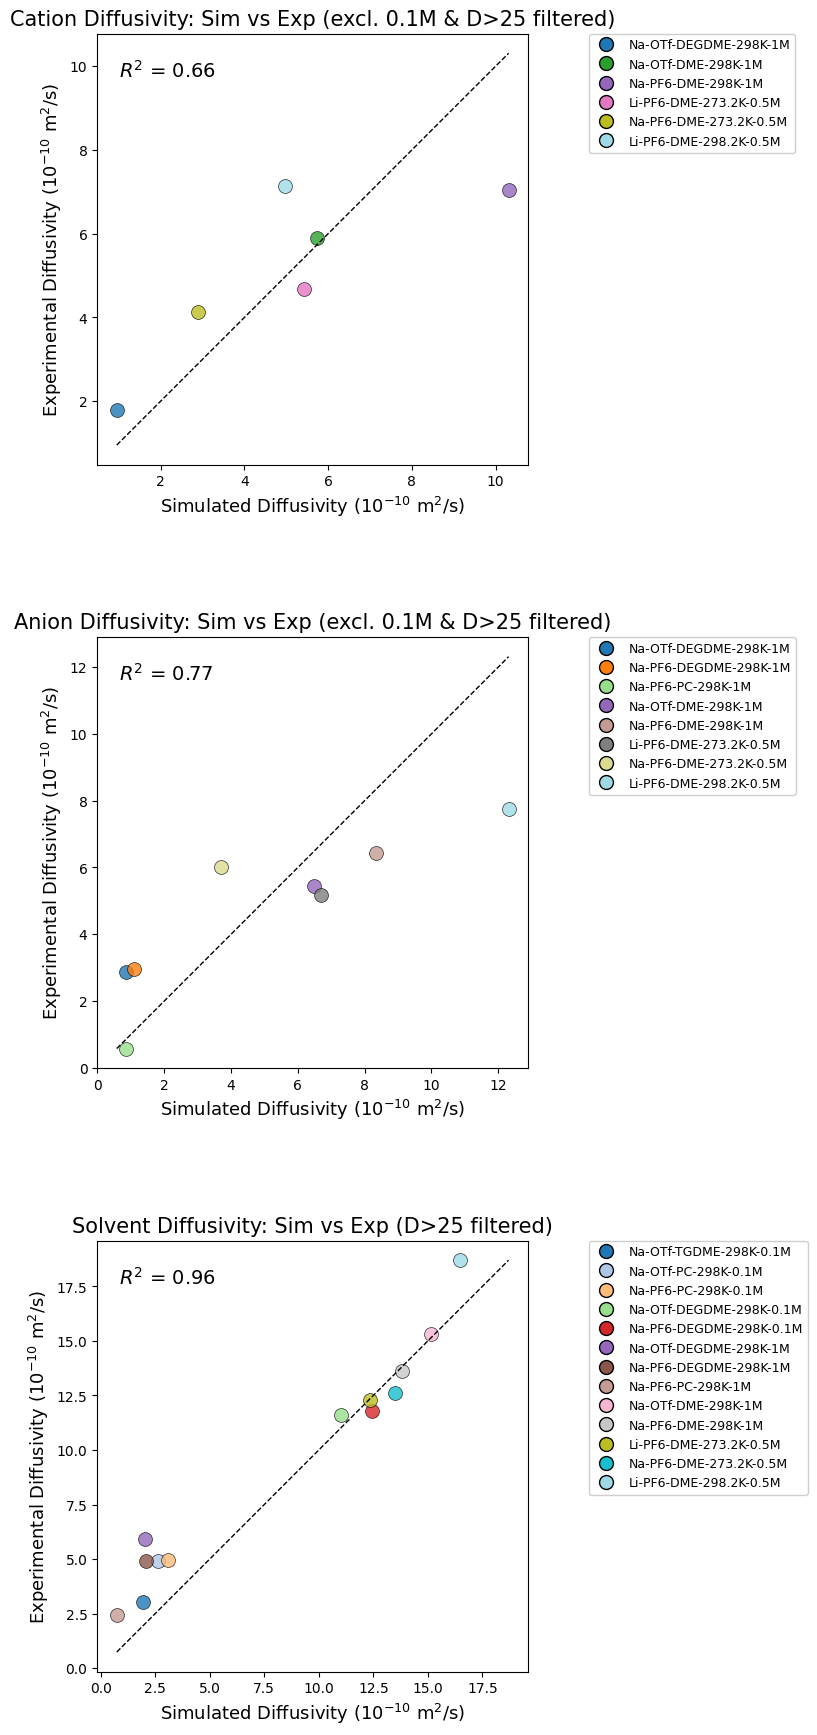

In [9]:
# Filter out rows where concentration is 0.1M for cation and anion R2
df_filtered = df.copy()
exclude_cation_anion = (df_filtered['concentration'] == '0.1M')

# Filter cation: exclude 0.1M and D > 25 for either sim or exp
mask_cation = (
    (~exclude_cation_anion) &
    (df_filtered['cation_diffusivity_simulated'].notnull()) &
    (df_filtered['cation_diffusivity_experimental'].notnull()) &
    (df_filtered['cation_diffusivity_simulated'].astype(float) <= 25) &
    (df_filtered['cation_diffusivity_experimental'].astype(float) <= 25)
)
x_cation = df_filtered.loc[mask_cation, 'cation_diffusivity_simulated'].astype(float).values
y_cation = df_filtered.loc[mask_cation, 'cation_diffusivity_experimental'].astype(float).values
labels_cation = df_filtered.loc[mask_cation, ['cation', 'anion', 'solvent', 'temperature', 'concentration']].astype(str).agg('-'.join, axis=1).values

# Filter anion: exclude 0.1M and D > 25 for either sim or exp
mask_anion = (
    (~exclude_cation_anion) &
    (df_filtered['anion_diffusivity_simulated'].notnull()) &
    (df_filtered['anion_diffusivity_experimental'].notnull()) &
    (df_filtered['anion_diffusivity_simulated'].astype(float) <= 25) &
    (df_filtered['anion_diffusivity_experimental'].astype(float) <= 25)
)
x_anion = df_filtered.loc[mask_anion, 'anion_diffusivity_simulated'].astype(float).values
y_anion = df_filtered.loc[mask_anion, 'anion_diffusivity_experimental'].astype(float).values
labels_anion = df_filtered.loc[mask_anion, ['cation', 'anion', 'solvent', 'temperature', 'concentration']].astype(str).agg('-'.join, axis=1).values

# Filter solvent: exclude D > 25 for either sim or exp
mask_solvent = (
    (df_filtered['solvent_diffusivity_simulated'].notnull()) &
    (df_filtered['solvent_diffusivity_experimental'].notnull()) &
    (df_filtered['solvent_diffusivity_simulated'].astype(float) <= 25) &
    (df_filtered['solvent_diffusivity_experimental'].astype(float) <= 25)
)
x_solvent = df_filtered.loc[mask_solvent, 'solvent_diffusivity_simulated'].astype(float).values
y_solvent = df_filtered.loc[mask_solvent, 'solvent_diffusivity_experimental'].astype(float).values
labels_solvent = df_filtered.loc[mask_solvent, ['cation', 'anion', 'solvent', 'temperature', 'concentration']].astype(str).agg('-'.join, axis=1).values

def plot_r2_unique_colors(ax, x, y, labels, title, colormap_name='tab20'):
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    num_points = len(x)
    cmap = cm.get_cmap(colormap_name, num_points)
    colors = [cmap(i) for i in range(num_points)]

    # Plot scatter points with unique colors
    handles = []
    for i, (xi, yi, label) in enumerate(zip(x, y, labels)):
        handle = ax.scatter([xi], [yi], alpha=0.8, color=[colors[i]], label=label, s=100, edgecolor='k', linewidth=0.5)
        handles.append(handle)

    # Plot y=x reference
    if len(x) > 0 and len(y) > 0:
        min_val = min(min(x), min(y))
        max_val = max(max(x), max(y))
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
    ax.set_xlabel('Simulated Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_ylabel('Experimental Diffusivity ($10^{-10}$ m$^2$/s)', fontsize=13)
    ax.set_title(title, fontsize=15)

    # Calculate R^2
    if len(x) > 1:
        correlation_matrix = np.corrcoef(x, y)
        r2 = correlation_matrix[0, 1] ** 2
        ax.text(0.05, 0.9, f"$R^2$ = {r2:.2f}", transform=ax.transAxes, fontsize=14,
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
    ax.set_aspect('equal', adjustable='box')

    # Create legend: Show all labels
    from matplotlib.lines import Line2D
    legend_handles = []
    for lab, col in zip(labels, colors):
        legend_handles.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=col,
                   markeredgecolor='k', markersize=10, label=lab)
        )
    ax.legend(handles=legend_handles, bbox_to_anchor=(1.14, 1), loc='upper left', fontsize=9, borderaxespad=0, framealpha=0.95)

# Create 3 rows (stacked vertically), 1 column, make plots tall and wide for space and clear separation
fig, axes = plt.subplots(3, 1, figsize=(14, 18), gridspec_kw={'hspace': 0.4})  # much bigger height, enough horizontal for legend

plot_r2_unique_colors(axes[0], x_cation, y_cation, labels_cation, "Cation Diffusivity: Sim vs Exp (excl. 0.1M & D>25 filtered)", colormap_name='tab20')
plot_r2_unique_colors(axes[1], x_anion, y_anion, labels_anion, "Anion Diffusivity: Sim vs Exp (excl. 0.1M & D>25 filtered)", colormap_name='tab20')
plot_r2_unique_colors(axes[2], x_solvent, y_solvent, labels_solvent, "Solvent Diffusivity: Sim vs Exp (D>25 filtered)", colormap_name='tab20')

# Adjust to give LOTS of space to legends and prevent overlap, bigger left/right margins, increase top/bottom, more vertical space
plt.subplots_adjust(left=0.10, right=0.78, bottom=0.06, top=0.97, hspace=0.36)
plt.show()


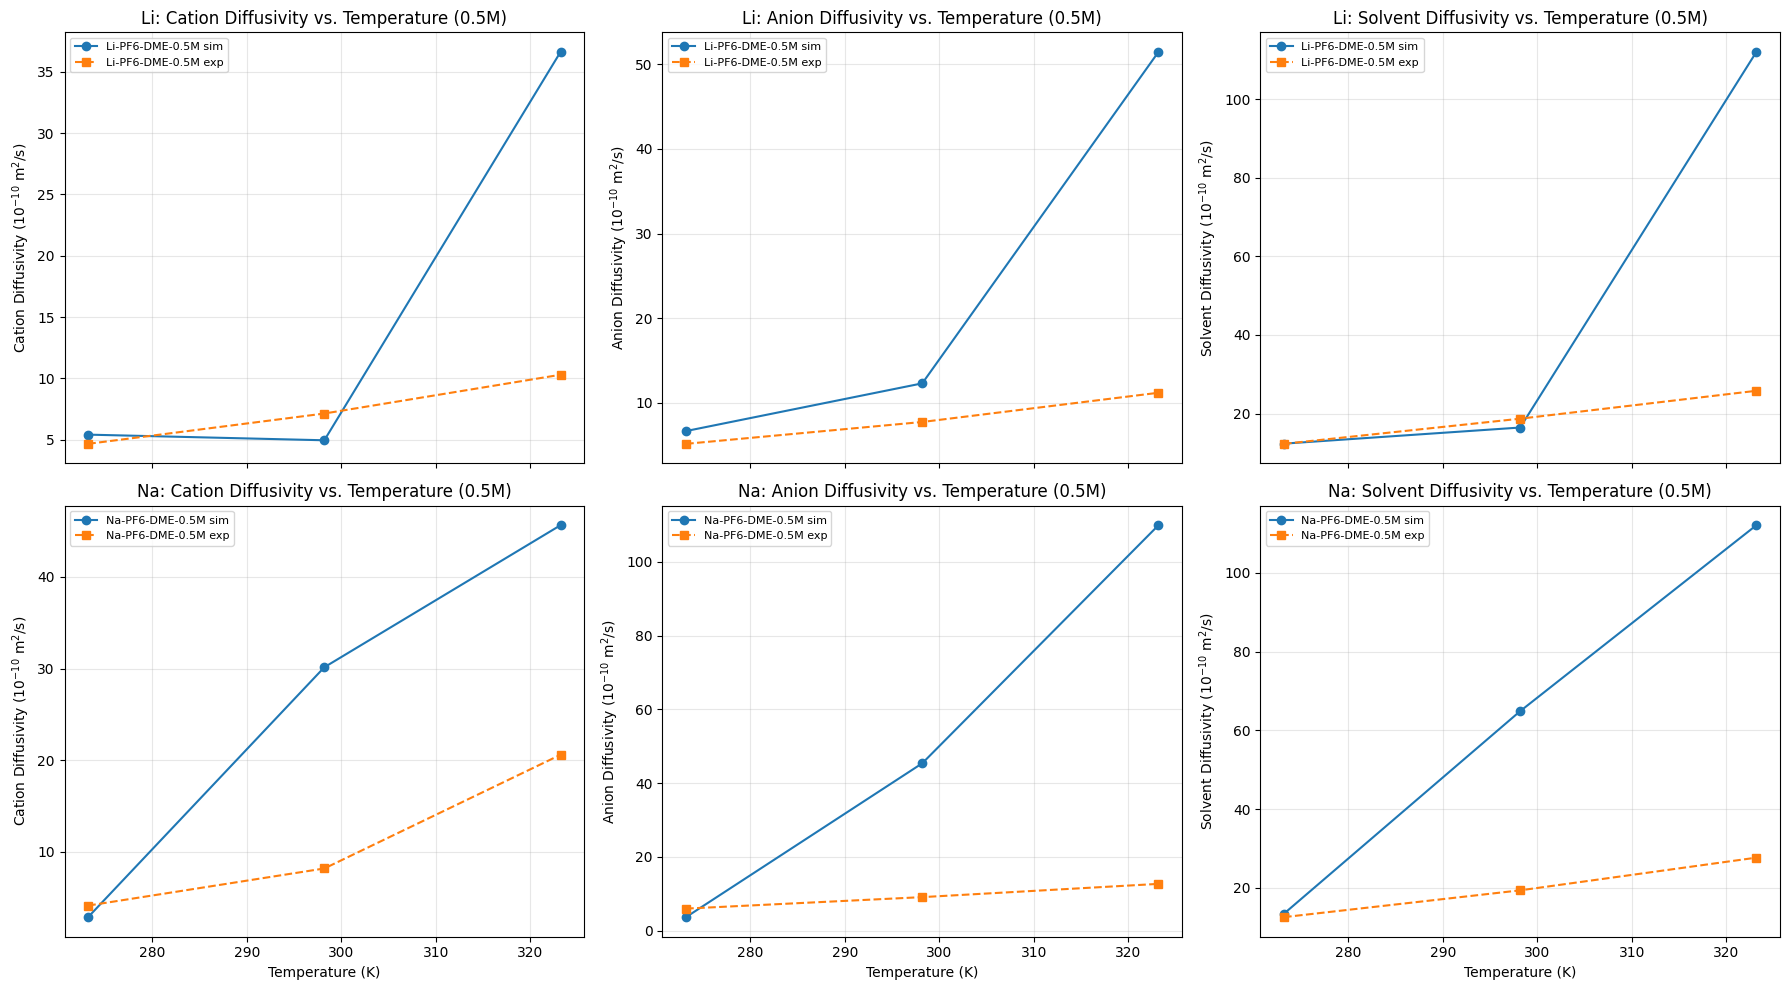

In [10]:
import matplotlib.pyplot as plt

# Only keep rows with concentration == '0.5M' 
df_05 = df[df['concentration'] == '0.5M'].copy()

def temp_to_float(temp_str):
    try:
        return float(str(temp_str).replace('K',''))
    except Exception:
        return None

df_05['temp_num'] = df_05['temperature'].apply(temp_to_float)
df_05 = df_05.sort_values('temp_num')

# Unique cation labels (should be 'Na' and 'Li' in this data set)
cation_labels = sorted(df_05['cation'].unique())
anion_labels = sorted(df_05['anion'].unique())
solvent_labels = sorted(df_05['solvent'].unique())

markers = {'sim':'o', 'exp':'s'}

# 2 rows, 3 columns grid (6 plots)
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

for cation_idx, cation in enumerate(cation_labels):
    df_cat = df_05[df_05['cation'] == cation]
    cat_anion_labels = sorted(df_cat['anion'].unique())
    cat_solvent_labels = sorted(df_cat['solvent'].unique())

    # Axes flattened access
    # row=0 for Li, row=1 for Na
    for i, (diff_type, sim_col, exp_col, ylab, title) in enumerate([
        ('cation', 'cation_diffusivity_simulated', 'cation_diffusivity_experimental', 'Cation Diffusivity ($10^{-10}$ m$^2$/s)', f"{cation}: Cation Diffusivity vs. Temperature (0.5M)"),
        ('anion', 'anion_diffusivity_simulated', 'anion_diffusivity_experimental', 'Anion Diffusivity ($10^{-10}$ m$^2$/s)', f"{cation}: Anion Diffusivity vs. Temperature (0.5M)"),
        ('solvent', 'solvent_diffusivity_simulated', 'solvent_diffusivity_experimental', 'Solvent Diffusivity ($10^{-10}$ m$^2$/s)', f"{cation}: Solvent Diffusivity vs. Temperature (0.5M)"),
    ]):
        row = cation_idx
        col = i
        ax = axes[row, col]
        for anion in cat_anion_labels:
            for solvent in cat_solvent_labels:
                mask = (df_cat['anion'] == anion) & (df_cat['solvent'] == solvent)
                sub = df_cat[mask]
                if sub.empty: continue
                concentration = None
                if not sub['concentration'].empty:
                    concentration = sub['concentration'].iloc[0]
                else:
                    concentration = 'unknown'
                label_id = f"{cation}-{anion}-{solvent}-{concentration}"
                # Simulated
                ax.plot(
                    sub['temp_num'], sub[sim_col], 
                    marker=markers['sim'], linestyle='-', 
                    label=f"{label_id} sim"
                )
                # Experimental
                ax.plot(
                    sub['temp_num'], sub[exp_col], 
                    marker=markers['exp'], linestyle='--', 
                    label=f"{label_id} exp"
                )
        ax.set_title(title)
        ax.set_ylabel(ylab)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        if row == 1:
            ax.set_xlabel('Temperature (K)')

plt.tight_layout()
plt.show()


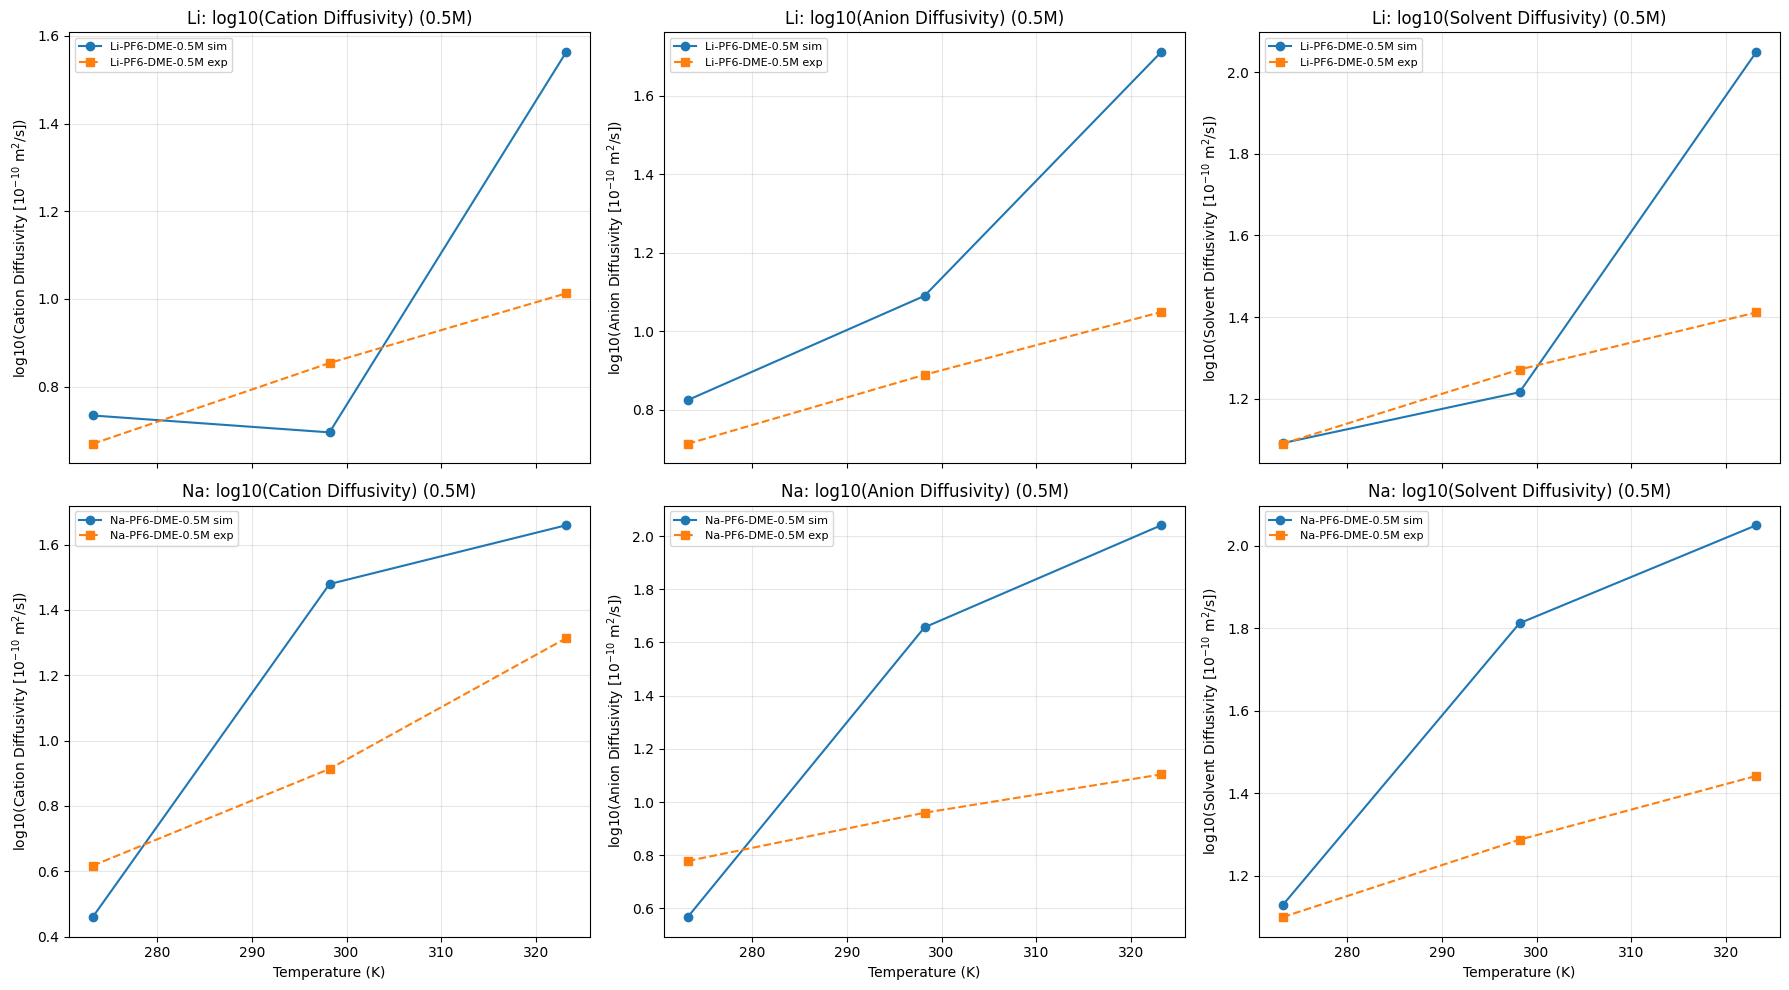

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Only keep rows with concentration == '0.5M' 
df_05 = df[df['concentration'] == '0.5M'].copy()

def temp_to_float(temp_str):
    try:
        return float(str(temp_str).replace('K',''))
    except Exception:
        return None

df_05['temp_num'] = df_05['temperature'].apply(temp_to_float)
df_05 = df_05.sort_values('temp_num')

# Apply np.log10 to all diffusivity columns (safe against non-positive values)
for col in ['cation_diffusivity_simulated', 'cation_diffusivity_experimental',
            'anion_diffusivity_simulated', 'anion_diffusivity_experimental',
            'solvent_diffusivity_simulated', 'solvent_diffusivity_experimental']:
    # avoid log of zero or negative: mask with np.nan
    df_05[col + '_log'] = np.where(df_05[col] > 0, np.log10(df_05[col]), np.nan)

# Unique cation labels (should be 'Na' and 'Li' in this data set)
cation_labels = sorted(df_05['cation'].unique())
anion_labels = sorted(df_05['anion'].unique())
solvent_labels = sorted(df_05['solvent'].unique())

markers = {'sim':'o', 'exp':'s'}

# 2 rows (for cations), 3 cols (diffusivity types)
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = np.array(axes)

for cation_idx, cation in enumerate(cation_labels):
    df_cat = df_05[df_05['cation'] == cation]
    cat_anion_labels = sorted(df_cat['anion'].unique())
    cat_solvent_labels = sorted(df_cat['solvent'].unique())
    
    # 1. Cation diffusivity (LOGPLOT) - col 0
    ax = axes[cation_idx, 0]
    for anion in cat_anion_labels:
        for solvent in cat_solvent_labels:
            mask = (df_cat['anion'] == anion) & (df_cat['solvent'] == solvent)
            sub = df_cat[mask]
            if sub.empty: continue
            concentration = None
            if not sub['concentration'].empty:
                concentration = sub['concentration'].iloc[0]
            else:
                concentration = 'unknown'
            label_id = f"{cation}-{anion}-{solvent}-{concentration}"
            # Simulated
            ax.plot(
                sub['temp_num'], sub['cation_diffusivity_simulated_log'], 
                marker=markers['sim'], linestyle='-', 
                label=f"{label_id} sim"
            )
            # Experimental
            ax.plot(
                sub['temp_num'], sub['cation_diffusivity_experimental_log'], 
                marker=markers['exp'], linestyle='--', 
                label=f"{label_id} exp"
            )
    ax.set_title(f'{cation}: log10(Cation Diffusivity) (0.5M)')
    ax.set_ylabel('log10(Cation Diffusivity [$10^{-10}$ m$^2$/s])')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    if cation_idx == len(cation_labels)-1:
        ax.set_xlabel('Temperature (K)')

    # 2. Anion diffusivity (LOGPLOT) - col 1
    ax = axes[cation_idx, 1]
    for anion in cat_anion_labels:
        for solvent in cat_solvent_labels:
            mask = (df_cat['anion']==anion) & (df_cat['solvent']==solvent)
            sub = df_cat[mask]
            if sub.empty: continue
            concentration = None
            if not sub['concentration'].empty:
                concentration = sub['concentration'].iloc[0]
            else:
                concentration = 'unknown'
            label_id = f"{cation}-{anion}-{solvent}-{concentration}"
            # Simulated
            ax.plot(
                sub['temp_num'], sub['anion_diffusivity_simulated_log'], 
                marker=markers['sim'], linestyle='-', 
                label=f"{label_id} sim"
            )
            # Experimental
            ax.plot(
                sub['temp_num'], sub['anion_diffusivity_experimental_log'], 
                marker=markers['exp'], linestyle='--', 
                label=f"{label_id} exp"
            )
    ax.set_title(f"{cation}: log10(Anion Diffusivity) (0.5M)")
    ax.set_ylabel('log10(Anion Diffusivity [$10^{-10}$ m$^2$/s])')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    if cation_idx == len(cation_labels)-1:
        ax.set_xlabel('Temperature (K)')

    # 3. Solvent diffusivity (LOGPLOT) - col 2
    ax = axes[cation_idx, 2]
    for anion in cat_anion_labels:
        for solvent in cat_solvent_labels:
            mask = (df_cat['anion']==anion) & (df_cat['solvent']==solvent)
            sub = df_cat[mask]
            if sub.empty: continue
            concentration = None
            if not sub['concentration'].empty:
                concentration = sub['concentration'].iloc[0]
            else:
                concentration = 'unknown'
            label_id = f"{cation}-{anion}-{solvent}-{concentration}"
            # Simulated
            ax.plot(
                sub['temp_num'], sub['solvent_diffusivity_simulated_log'], 
                marker=markers['sim'], linestyle='-', 
                label=f"{label_id} sim"
            )
            # Experimental
            ax.plot(
                sub['temp_num'], sub['solvent_diffusivity_experimental_log'], 
                marker=markers['exp'], linestyle='--', 
                label=f"{label_id} exp"
            )
    ax.set_title(f"{cation}: log10(Solvent Diffusivity) (0.5M)")
    ax.set_ylabel('log10(Solvent Diffusivity [$10^{-10}$ m$^2$/s])')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    if cation_idx == len(cation_labels)-1:
        ax.set_xlabel('Temperature (K)')

plt.tight_layout()
plt.show()
